In [19]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score,
    f1_score,
    recall_score,
    roc_curve,
    classification_report
)

In [7]:
DATA_PATH = "../Data/Preprocessed_data.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLD = 5

In [5]:
df = pd.read_csv(DATA_PATH)
df.head()

,person_age,person_income,person_monthly_income,person_emp_length,emp_stability,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,person_home_ownership_OTHER,credit_hist_ratio,debt_burden_index,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,3.091042,9.169623,6.685861,1.791759,0.215111,1,6.908755,2.496506,0,0.095310,...,0,0.10,0.113329,1,0,1,0,0,0,0
1,3.258097,9.169623,6.685861,0.693147,0.039221,2,8.612685,2.629728,1,0.451076,...,0,0.12,0.500775,0,0,0,0,1,0,0
2,3.178054,11.089821,8.605081,1.609438,0.157004,2,10.463132,2.786861,1,0.425268,...,0,0.09,0.482426,0,1,0,0,1,0,0
3,3.218876,10.904138,8.419433,2.197225,0.285179,2,10.463132,2.725890,1,0.438255,...,0,0.17,0.553885,0,1,0,0,1,0,0
4,3.091042,9.200391,6.716595,1.098612,0.095310,0,7.824446,2.096790,1,0.223144,...,0,0.10,0.239017,1,0,0,0,0,0,1


In [6]:
x = df.drop(['loan_status'], axis=1)
y = df['loan_status']

In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=TEST_SIZE, 
    stratify=y, random_state= RANDOM_STATE
)

In [9]:
algorithms = {
    "LogisticRegression": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBClassifier": XGBClassifier(random_state = RANDOM_STATE)
}

# model training without scalling

In [10]:
result_list = []

for model_name, models in algorithms.items():
    model = models.fit(xtrain, ytrain)
    y_pred = model.predict(xtest)

    result_list.append({
        'Model': model_name,
        'Train Score': model.score(xtrain, ytrain),
        'Test Score': model.score(xtest, ytest),
        'accuracy_score': accuracy_score(ytest, y_pred),
        'Recall': recall_score(ytest, y_pred),
        'f1_score': f1_score(ytest, y_pred),
        'Confusion Matrix': confusion_matrix(ytest, y_pred)
    })

result = pd.DataFrame(result_list)

In [11]:
print("Without Scalling")
result.sort_values(by='accuracy_score', ascending=False)

Without Scalling


,Model,Train Score,Test Score,accuracy_score,Recall,f1_score,Confusion Matrix
2,XGBClassifier,0.960206,0.937956,0.937956,0.753857,0.839951,"[[4885, 56], [335, 1026]]"
1,RandomForestClassifier,1.000000,0.936052,0.936052,0.733284,0.832013,"[[4901, 40], [363, 998]]"
0,LogisticRegression,0.860266,0.861473,0.861473,0.529023,0.622568,"[[4709, 232], [641, 720]]"


In [12]:
scale_xtrain = xtrain.copy()
scale_xtest = xtest.copy()

In [13]:
scaler = StandardScaler()
scale_xtrain = scaler.fit_transform(scale_xtrain)
scale_xtest = scaler.transform(scale_xtest)

In [14]:
smote = SMOTE()
scale_xtrain_res, scale_ytrain_res = smote.fit_resample(scale_xtrain, ytrain)

In [15]:
result_list_2 = []

for model_name, models in algorithms.items():
    model = models.fit(scale_xtrain_res, scale_ytrain_res)
    y_pred = model.predict(scale_xtest)

    result_list_2.append({
        'Model': model_name,
        'Train Score': model.score(scale_xtrain_res, scale_ytrain_res),
        'Test Score': model.score(scale_xtest, ytest),
        'Accuracy': accuracy_score(ytest, y_pred),
        'Recall': recall_score(ytest, y_pred),
        'f1_score': f1_score(ytest, y_pred),
        'Confusion Matrix': confusion_matrix(ytest, y_pred)
    })

result_2 = pd.DataFrame(result_list_2)

In [16]:
print("With Scalling")
result_2.sort_values(by='Accuracy', ascending=False)

With Scalling


,Model,Train Score,Test Score,Accuracy,Recall,f1_score,Confusion Matrix
2,XGBClassifier,0.970749,0.93510,0.93510,0.751653,0.833401,"[[4870, 71], [338, 1023]]"
1,RandomForestClassifier,1.000000,0.93034,0.93034,0.742101,0.821472,"[[4853, 88], [351, 1010]]"
0,LogisticRegression,0.801392,0.79927,0.79927,0.785452,0.628269,"[[3968, 973], [292, 1069]]"


# Model train & Evaluation Function

In [20]:
def evaluate_model(model, xtrain, xtest, ytrain, ytest, model_name):
    xtrain_pred = model.predict(xtrain)
    y_pred = model.predict(xtest)
    y_pred_proba = model.predict_proba(xtest)[:, 1]

    train_recall = recall_score(ytrain, xtrain_pred)
    test_recall = recall_score(ytest, y_pred)

    accuracay = accuracy_score(ytest, y_pred)
    recall = recall_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)
    confusion = confusion_matrix(ytest, y_pred)
    roc_auc = roc_auc_score(ytest, y_pred_proba)
    
    best_param = model.best_param_ if hasattr(model, 'best_param_') else None
    best_score = model.best_score_ if hasattr(model, 'best_score_') else None

    result = pd.DataFrame([{
        'Model' : model_name,
        'Train Recall' : train_recall,
        'Test Recall' : test_recall,
        'Accuracay' : accuracay,
        'Recall Score' : recall,
        'F1 Score' : f1,
        'Confusion': confusion,
        'Roc Auc': roc_auc,
        'Best Score' : best_score
    }])
    
    print(f"{model_name} - Evaluation Report")
    print(f"{'_'*20}")
    print(classification_report(ytest, y_pred, target_names=['No Default', 'Default']))
    print(f"ROC AUC: {roc_auc:.4f}")
    if best_param:
        print(f"Best Param: {best_param}")

    return result, y_pred_proba, confusion, roc_auc

# XGB Classifier


In [ ]:
xg_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric = 'logloss',
        random_state = RANDOM_STATE, 
        n_jobs = 1
    ))
])

xg_param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xg_cv = StratifiedKFold(
    n_splits=CV_FOLD, 
    shuffle= True,
    random_state=RANDOM_STATE
)

xg_Rsearchcv = RandomizedSearchCV(
    estimator=xg_pipeline,
    param_distributions = xg_param_dist,
    scoring = 'recall',
    cv = xg_cv,
    verbose=1, 
    n_jobs=-1
)

xg_model = xg_Rsearchcv.fit(xtrain, ytrain)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [15]:
xg_result, xg_pred_proba, xg_confusion, xg_roc_auc = evaluate_model(
    model=xg_model,
    xtrain=xtrain, 
    xtest=xtest,
    ytrain=ytrain, 
    ytest=ytest,
    model_name='XGB Classifier'
)
xg_result

,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Confusion,Roc Auc,Best Score
0,XGB Classifier,0.77539,0.783248,0.889718,0.783248,0.754156,"[[4541, 400], [295, 1066]]",0.926989,0.773003


# Random Forest Classifier

In [ ]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

rf_cv = StratifiedKFold(
    n_splits=3, 
    shuffle= True,
    random_state=42
)

rf_grid_cv = RandomizedSearchCV(
    estimator= rf_pipeline,
    param_distributions= rf_param_grid,
    scoring='recall',
    cv=rf_cv, n_iter=10,
    verbose=1, n_jobs=-1
)
rf_model = rf_grid_cv.fit(xtrain, ytrain) 

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [26]:
rf_result, rf_pred_proba, rf_confusion, rf_roc_auc = evaluate_model(
    model = rf_model,
    xtrain = xtrain,
    xtest= xtest, 
    ytrain=ytrain,
    ytest= ytest,
    model_name = 'Random Forest Classifier'
)
rf_result

,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Confusion,Roc Auc,Best Score
0,Random Forest Classifier,1.0,0.753857,0.927325,0.753857,0.81753,"[[4818, 123], [335, 1026]]",0.936073,0.922872


In [27]:
comparing = pd.concat([xg_result, rf_result], ignore_index=True)
comparing.sort_values(by='Recall Score', ascending=False)

,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Confusion,Roc Auc,Best Score
0,XGB Classifier,0.77539,0.783248,0.889718,0.783248,0.754156,"[[4541, 400], [295, 1066]]",0.926989,0.773003
1,Random Forest Classifier,1.00000,0.753857,0.927325,0.753857,0.817530,"[[4818, 123], [335, 1026]]",0.936073,0.922872


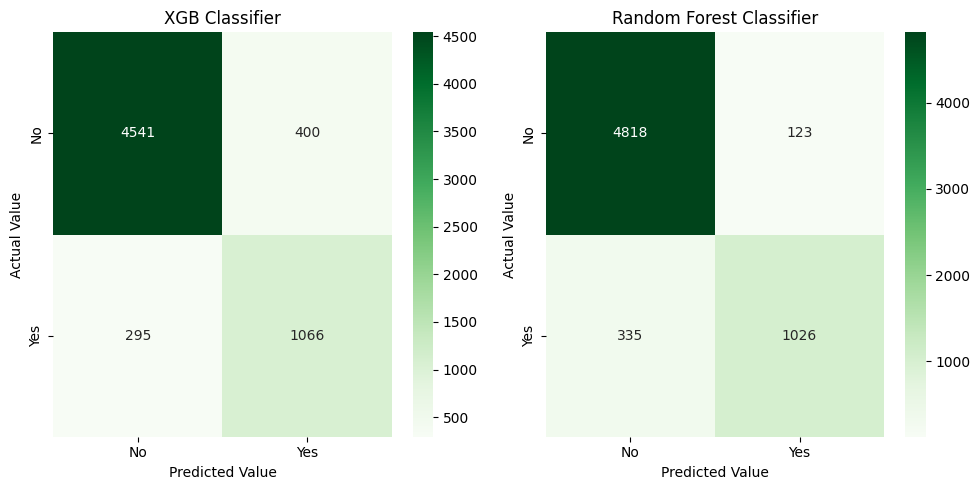

In [34]:
confusion_matrixes = [xg_confusion, rf_confusion]
titles = ['XGB Classifier', 'Random Forest Classifier']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
labels = ["No", "Yes"]

for ax, cm, title, in zip(axes.flatten(), confusion_matrixes, titles):
    sns.heatmap(
        cm, annot=True, fmt='g', cmap='Greens',
        ax=ax, xticklabels=labels, yticklabels=labels
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Value")
    ax.set_ylabel("Actual Value")
plt.tight_layout()
plt.show()


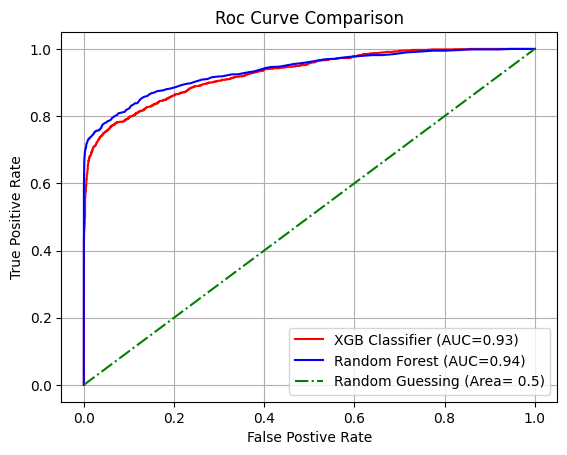

In [42]:
fpr1, tpr1, _ = roc_curve(ytest, xg_pred_proba)
fpr2, tpr2, _ = roc_curve(ytest, rf_pred_proba)

plt.plot(fpr1, tpr1, color='red', label= f"XGB Classifier (AUC={xg_roc_auc:.2f})")
plt.plot(fpr2, tpr2, color='blue', label= f"Random Forest (AUC={rf_roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color='green', linestyle='-.', label="Random Guessing (Area= 0.5)")

plt.title("Roc Curve Comparison")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')        
plt.grid(True)                     
plt.show() 